In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRanker, Pool

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 4 if torch.cuda.is_available() else 0
print(f'Device: {device}, num_workers: {NUM_WORKERS}')

shap not installed — beeswarm plot будет пропущен. pip install shap чтобы включить.
Device: cpu, num_workers: 0


In [2]:
DATA_PATH = '../data/children_products/clildren_product_cleaned.csv'
MIN_INTERACTIONS = 3
SPLIT_QUANTILE = 0.7
K_VALUES = [5, 10, 20]
N_CANDIDATES = 100
BATCH_SIZE = 1024

df = pd.read_csv(DATA_PATH, low_memory=False)
df = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df = df.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
df = df.dropna(subset=['Дата'])

if 'Цена' in df.columns:
    df['Цена'] = df['Цена'].astype(str).str.replace(' ', '').str.replace(',', '.')
    df['Цена'] = pd.to_numeric(df['Цена'], errors='coerce')

uc = df.groupby('Телефон_new').size()
ic = df.groupby('ID_SKU').size()
df = df[
    df['Телефон_new'].isin(uc[uc >= MIN_INTERACTIONS].index) &
    df['ID_SKU'].isin(ic[ic >= MIN_INTERACTIONS].index)
]
print(f'After filter: users={df["Телефон_new"].nunique():,}, '
      f'items={df["ID_SKU"].nunique():,}, rows={len(df):,}')
# expected: 35,395 / 22,198 / 314,493

After filter: users=35,395, items=22,198, rows=314,493


In [3]:
interactions = (
    df.groupby(['Телефон_new', 'ID_SKU'])
      .agg(last_date=('Дата', 'max'),
           mean_date=('Дата', 'mean'),
           count=('Дата', 'count'))
      .reset_index()
)

user_enc = LabelEncoder()
item_enc = LabelEncoder()
interactions['user_id'] = user_enc.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_enc.fit_transform(interactions['ID_SKU'])

df['user_id'] = user_enc.transform(df['Телефон_new'])
df['item_id'] = item_enc.transform(df['ID_SKU'])

N_USERS = interactions['user_id'].nunique()
N_ITEMS = interactions['item_id'].nunique()
print(f'Unique pairs: {len(interactions):,}, N_USERS={N_USERS:,}, N_ITEMS={N_ITEMS:,}')
# expected: 287,360 / 35,395 / 22,198

Unique pairs: 287,360, N_USERS=35,395, N_ITEMS=22,198


In [4]:
split_ts = interactions['last_date'].quantile(SPLIT_QUANTILE)
print(f'Split timestamp: {split_ts}')

train_df = interactions[interactions['last_date'] <  split_ts].copy()
test_df  = interactions[interactions['last_date'] >= split_ts].copy()

train_users = set(train_df['user_id'].unique())
test_warm = test_df[test_df['user_id'].isin(train_users)].copy()

train_raw = df[df['Дата'] < split_ts].copy()

print(f'Train pairs: {len(train_df):,} / {train_df["user_id"].nunique():,} users')
print(f'Test warm:   {len(test_warm):,} / {test_warm["user_id"].nunique():,} users')
print(f'Train raw transactions: {len(train_raw):,}')
# expected: 201,147 / 28,017; 42,415 / 7,128

Split timestamp: 2017-04-12 17:37:00
Train pairs: 201,147 / 28,017 users
Test warm:   42,415 / 7,128 users
Train raw transactions: 225,586


In [ ]:
NCF_BEST_N_FACTORS = 82
NCF_BEST_LR        = 1.31e-3
NCF_BEST_LAYERS    = [128, 64]
NCF_BEST_N_NEG     = 8
NCF_BEST_DROPOUT   = 0.31
NCF_FINAL_EPOCHS   = 20

NCF_USE_TIME_DECAY = False
NCF_BEST_LAMBDA    = 0.01

print(f'NCF hyperparams: factors={NCF_BEST_N_FACTORS}, lr={NCF_BEST_LR:.2e}, '
      f'layers={NCF_BEST_LAYERS}, n_neg={NCF_BEST_N_NEG}, dropout={NCF_BEST_DROPOUT}, '
      f'epochs={NCF_FINAL_EPOCHS}, decay={NCF_USE_TIME_DECAY} (λ={NCF_BEST_LAMBDA})')

NCF hyperparams: factors=82, lr=1.31e-03, layers=[128, 64], n_neg=8, dropout=0.31, epochs=20, decay=False (λ=0.01)


In [6]:
def generate_negatives(interactions_df, n_items, n_neg, rng):
    user_items = interactions_df.groupby('user_id')['item_id'].apply(set).to_dict()
    pos_users  = interactions_df['user_id'].values
    n_pos = len(pos_users)
    candidates = rng.integers(0, n_items, size=(n_pos, n_neg * 3))
    neg_users, neg_items = [], []
    for i, u in enumerate(pos_users):
        u_set = user_items.get(int(u), set())
        valid = [c for c in candidates[i] if c not in u_set][:n_neg]
        while len(valid) < n_neg:
            c = int(rng.integers(0, n_items))
            if c not in u_set:
                valid.append(c)
        neg_users.extend([u] * n_neg)
        neg_items.extend(valid)
    return np.array(neg_users, dtype=np.int64), np.array(neg_items, dtype=np.int64)


class NCFDataset(Dataset):
    def __init__(self, interactions_df, n_items, n_neg=4, decay_weights=None, seed=SEED):
        rng = np.random.default_rng(seed)
        pos_users   = interactions_df['user_id'].values
        pos_items   = interactions_df['item_id'].values
        pos_labels  = np.ones(len(pos_users), dtype=np.float32)
        pos_weights = (
            np.asarray(decay_weights, dtype=np.float32)
            if decay_weights is not None
            else np.ones(len(pos_users), dtype=np.float32)
        )

        neg_users, neg_items = generate_negatives(interactions_df, n_items, n_neg, rng)
        neg_labels  = np.zeros(len(neg_users), dtype=np.float32)
        neg_weights = np.ones(len(neg_users),  dtype=np.float32)

        all_users   = np.concatenate([pos_users,   neg_users])
        all_items   = np.concatenate([pos_items,   neg_items])
        all_labels  = np.concatenate([pos_labels,  neg_labels])
        all_weights = np.concatenate([pos_weights, neg_weights])

        idx = rng.permutation(len(all_users))
        self.users   = torch.from_numpy(all_users[idx])
        self.items   = torch.from_numpy(all_items[idx])
        self.labels  = torch.from_numpy(all_labels[idx])
        self.weights = torch.from_numpy(all_weights[idx])
        print(f'Dataset: {len(self):,} samples ({len(pos_users):,} pos + {len(neg_users):,} neg)')

    def __len__(self):  return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx], self.weights[idx]


def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=True):
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
    )

In [7]:
class NeuMF(nn.Module):
    def __init__(self, n_users, n_items, n_factors=64, layer_sizes=None, dropout=0.3):
        super().__init__()
        if layer_sizes is None:
            layer_sizes = [256, 128, 64]

        self.user_emb_gmf = nn.Embedding(n_users, n_factors)
        self.item_emb_gmf = nn.Embedding(n_items, n_factors)
        self.user_emb_mlp = nn.Embedding(n_users, n_factors)
        self.item_emb_mlp = nn.Embedding(n_items, n_factors)

        mlp_layers, in_dim = [], n_factors * 2
        for out_dim in layer_sizes:
            mlp_layers += [
                nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim),
                nn.ReLU(), nn.Dropout(dropout),
            ]
            in_dim = out_dim
        self.mlp = nn.Sequential(*mlp_layers)

        self.fc_out = nn.Linear(n_factors + layer_sizes[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [self.user_emb_gmf, self.item_emb_gmf,
                    self.user_emb_mlp, self.item_emb_mlp]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.zeros_(self.fc_out.bias)

    def forward(self, users, items):
        gmf_out = self.user_emb_gmf(users) * self.item_emb_gmf(items)
        mlp_in  = torch.cat([self.user_emb_mlp(users), self.item_emb_mlp(items)], dim=-1)
        mlp_out = self.mlp(mlp_in)
        x = torch.cat([gmf_out, mlp_out], dim=-1)
        return torch.sigmoid(self.fc_out(x).squeeze(-1))


def train_model(model, loader, n_epochs, lr=1e-3, verbose=2):
    criterion = nn.BCELoss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    model.to(device)
    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss, t0 = 0.0, time.time()
        for users, items, labels, weights in loader:
            users   = users.to(device, non_blocking=True)
            items   = items.to(device, non_blocking=True)
            labels  = labels.to(device, non_blocking=True)
            weights = weights.to(device, non_blocking=True)
            preds = model(users, items)
            loss  = (criterion(preds, labels) * weights).mean()
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1 or epoch == n_epochs):
            print(f'Epoch {epoch:>3}/{n_epochs}  loss={avg:.4f}  [{time.time()-t0:.1f}s]')


@torch.no_grad()
def score_all_items(model, user_ids, n_items, user_batch=32):
    model.eval(); model.to(device)
    item_t = torch.arange(n_items, device=device)
    out = torch.empty(len(user_ids), n_items)
    for start in range(0, len(user_ids), user_batch):
        batch = user_ids[start:start + user_batch]
        b = len(batch)
        u = torch.tensor(batch, device=device).unsqueeze(1).expand(b, n_items).reshape(-1)
        v = item_t.unsqueeze(0).expand(b, -1).reshape(-1)
        scores = model(u, v).reshape(b, n_items)
        out[start:start + b] = scores.cpu()
    return out

In [8]:
if NCF_USE_TIME_DECAY:
    days = (split_ts - train_df['mean_date']).dt.total_seconds().values / 86400
    days = np.clip(days, 0, None)
    decay_weights = np.exp(-NCF_BEST_LAMBDA * days).clip(1e-6).astype(np.float32)
    print(f'Time-decay weights: [{decay_weights.min():.4f}, {decay_weights.max():.4f}]')
else:
    decay_weights = None

train_dataset = NCFDataset(train_df, N_ITEMS, n_neg=NCF_BEST_N_NEG, decay_weights=decay_weights)
train_loader  = make_loader(train_dataset)

ncf_model = NeuMF(
    N_USERS, N_ITEMS,
    n_factors=NCF_BEST_N_FACTORS,
    layer_sizes=NCF_BEST_LAYERS,
    dropout=NCF_BEST_DROPOUT,
)
n_params = sum(p.numel() for p in ncf_model.parameters())
print(f'NeuMF parameters: {n_params:,}')

t0 = time.time()
train_model(ncf_model, train_loader, n_epochs=NCF_FINAL_EPOCHS, lr=NCF_BEST_LR, verbose=2)
print(f'NCF обучен за {time.time()-t0:.0f}s')

Dataset: 1,810,323 samples (201,147 pos + 1,609,176 neg)
NeuMF parameters: 9,475,159
Epoch   1/20  loss=0.2819  [34.4s]
Epoch   2/20  loss=0.2473  [34.2s]
Epoch   4/20  loss=0.2222  [34.4s]
Epoch   6/20  loss=0.1985  [34.4s]
Epoch   8/20  loss=0.1739  [34.3s]
Epoch  10/20  loss=0.1530  [34.6s]
Epoch  12/20  loss=0.1357  [34.4s]
Epoch  14/20  loss=0.1225  [34.9s]
Epoch  16/20  loss=0.1120  [33.9s]
Epoch  18/20  loss=0.1037  [34.0s]
Epoch  20/20  loss=0.0975  [34.6s]
NCF обучен за 691s


In [9]:
def precision_at_k(rec, rel, k):
    rec_k = set(rec[:k]); rel = set(rel)
    return len(rec_k & rel) / len(rec_k) if rec_k else 0.0

def recall_at_k(rec, rel, k):
    rec_k = set(rec[:k]); rel = set(rel)
    return len(rec_k & rel) / len(rel) if rel else 0.0

def map_at_k(rec, rel, k):
    rel = set(rel)
    if not rel: return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(rec[:k]):
        if item in rel:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(rel), k)

def ndcg_at_k(rec, rel, k):
    rel = set(rel)
    if not rel: return 0.0
    dcg  = sum(1.0 / np.log2(i + 2) for i, it in enumerate(rec[:k]) if it in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0

def aggregate_metrics(per_user, k_values):
    return {
        k: {m: float(np.mean(per_user[k][m])) for m in ['precision','recall','map','ndcg']}
        for k in k_values
    }

In [10]:
test_user_items = test_warm.groupby('user_id')['item_id'].apply(list).to_dict()
train_user_bought = train_df.groupby('user_id')['item_id'].apply(set).to_dict()

eval_users = sorted([u for u in test_user_items if u in train_users])
print(f'Eval users (warm): {len(eval_users):,}')

USER_BATCH_SCORE = 32
t0 = time.time()
all_scores = score_all_items(ncf_model, eval_users, N_ITEMS, user_batch=USER_BATCH_SCORE)
print(f'Scored {len(eval_users)} users в {time.time()-t0:.1f}s; shape={tuple(all_scores.shape)}')

ncf_per_user = {k: {'precision':[],'recall':[],'map':[],'ndcg':[]} for k in K_VALUES}
max_k = max(K_VALUES)
for i, u in enumerate(eval_users):
    s = all_scores[i].clone()
    for it in train_user_bought.get(u, set()):
        if it < N_ITEMS:
            s[it] = -1e9
    _, top_idx = torch.topk(s, max_k)
    rec = top_idx.tolist()
    rel = test_user_items[u]
    for k in K_VALUES:
        ncf_per_user[k]['precision'].append(precision_at_k(rec, rel, k))
        ncf_per_user[k]['recall'].append(recall_at_k(rec, rel, k))
        ncf_per_user[k]['map'].append(map_at_k(rec, rel, k))
        ncf_per_user[k]['ndcg'].append(ndcg_at_k(rec, rel, k))

ncf_results = aggregate_metrics(ncf_per_user, K_VALUES)
print('=== NCF baseline ===')
for k in K_VALUES:
    r = ncf_results[k]
    print(f'  K={k}: P={r["precision"]:.4f}  R={r["recall"]:.4f}  '
          f'MAP={r["map"]:.4f}  NDCG={r["ndcg"]:.4f}')

Eval users (warm): 7,128
Scored 7128 users в 52.4s; shape=(7128, 22198)
=== NCF baseline ===
  K=5: P=0.0228  R=0.0310  MAP=0.0187  NDCG=0.0310
  K=10: P=0.0202  R=0.0518  MAP=0.0195  NDCG=0.0374
  K=20: P=0.0172  R=0.0803  MAP=0.0211  NDCG=0.0463


In [11]:
rows = []
for i, u in enumerate(eval_users):
    s = all_scores[i].clone()
    for it in train_user_bought.get(u, set()):
        if it < N_ITEMS:
            s[it] = -1e9
    top_scores, top_idx = torch.topk(s, N_CANDIDATES)
    rel = set(test_user_items[u])
    for rank, (it, sc) in enumerate(zip(top_idx.tolist(), top_scores.tolist())):
        rows.append({
            'user_id':   u,
            'item_id':   int(it),
            'ncf_score': float(sc),
            'ncf_rank':  rank + 1,
            'label':     int(int(it) in rel),
        })
candidates_df = pd.DataFrame(rows)
print(f'Кандидатов: {len(candidates_df):,}; positive ratio: {candidates_df["label"].mean():.4f}')

Кандидатов: 712,800; positive ratio: 0.0092


In [12]:
user_features = train_raw.groupby('user_id').agg(
    user_n_purchases=('Дата', 'count'),
    user_n_unique_items=('item_id', 'nunique'),
    user_avg_price=('Цена', 'mean'),
    user_total_margin=('Маржа', 'sum'),
    user_avg_margin=('Маржа', 'mean'),
).reset_index()

user_geo = train_raw.groupby('user_id')['Гео'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
user_geo.columns = ['user_id', 'user_geo']

user_delivery = train_raw.groupby('user_id')['МетодДоставки_Групп'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
user_delivery.columns = ['user_id', 'user_delivery_method']

user_features = user_features.merge(user_geo, on='user_id').merge(user_delivery, on='user_id')
print(f'User features: {user_features.shape}')

User features: (28469, 8)


In [13]:
item_features = train_raw.groupby('item_id').agg(
    item_n_purchases=('Дата', 'count'),
    item_n_unique_buyers=('user_id', 'nunique'),
    item_avg_price=('Цена', 'mean'),
    item_avg_margin=('Маржа', 'mean'),
).reset_index()

item_category = train_raw.groupby('item_id')['Группа2'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
item_category.columns = ['item_id', 'item_category']

item_features = item_features.merge(item_category, on='item_id')
print(f'Item features: {item_features.shape}')

Item features: (20745, 6)


In [14]:
dataset = candidates_df.merge(user_features, on='user_id', how='left')
dataset = dataset.merge(item_features, on='item_id', how='left')

# NCF GMF embeddings → dot/cosine/norms
user_emb = ncf_model.user_emb_gmf.weight.detach().cpu().numpy()  # (N_USERS, n_factors)
item_emb = ncf_model.item_emb_gmf.weight.detach().cpu().numpy()  # (N_ITEMS, n_factors)

u_vecs = user_emb[dataset['user_id'].values]
i_vecs = item_emb[dataset['item_id'].values]
dataset['ncf_dot']       = (u_vecs * i_vecs).sum(axis=1)
dataset['ncf_user_norm'] = np.linalg.norm(u_vecs, axis=1)
dataset['ncf_item_norm'] = np.linalg.norm(i_vecs, axis=1)
dataset['ncf_cosine']    = dataset['ncf_dot'] / (
    dataset['ncf_user_norm'] * dataset['ncf_item_norm'] + 1e-10
)

num_cols = [c for c in dataset.select_dtypes(include=[np.number]).columns
            if c not in {'user_id', 'item_id', 'label'}]
for c in num_cols:
    dataset[c] = dataset[c].fillna(dataset[c].median())
for c in ['user_geo', 'user_delivery_method', 'item_category']:
    dataset[c] = dataset[c].fillna('Неизвестно')

print(f'Dataset shape: {dataset.shape}')
print(f'Missing: {dataset.isnull().sum().sum()}')

Dataset shape: (712800, 21)
Missing: 0


In [15]:
FEATURE_COLS = [
    'ncf_score', 'ncf_rank', 'ncf_dot', 'ncf_cosine',
    'ncf_user_norm', 'ncf_item_norm',
    'user_n_purchases', 'user_n_unique_items', 'user_avg_price',
    'user_total_margin', 'user_avg_margin',
    'user_geo', 'user_delivery_method',
    'item_n_purchases', 'item_n_unique_buyers',
    'item_avg_price', 'item_avg_margin', 'item_category',
]
CAT_FEATURES = ['user_geo', 'user_delivery_method', 'item_category']

all_users_arr = np.array(eval_users)
rng = np.random.default_rng(SEED)
rng.shuffle(all_users_arr)
split_idx = int(len(all_users_arr) * 0.8)
cb_train_users = set(all_users_arr[:split_idx])
cb_val_users   = set(all_users_arr[split_idx:])

cb_train = dataset[dataset['user_id'].isin(cb_train_users)].sort_values('user_id').copy()
cb_val   = dataset[dataset['user_id'].isin(cb_val_users)].sort_values('user_id').copy()

print(f'CatBoost train: {len(cb_train):,} строк, {len(cb_train_users):,} users')
print(f'CatBoost val:   {len(cb_val):,} строк, {len(cb_val_users):,} users')
print(f'Features: {len(FEATURE_COLS)} (категориальных: {len(CAT_FEATURES)})')


def make_pool(df_part, feature_cols, cat_features):
    return Pool(
        data=df_part[feature_cols],
        label=df_part['label'],
        group_id=df_part['user_id'],
        cat_features=cat_features,
    )

train_pool = make_pool(cb_train, FEATURE_COLS, CAT_FEATURES)
val_pool   = make_pool(cb_val,   FEATURE_COLS, CAT_FEATURES)

CatBoost train: 570,200 строк, 5,702 users
CatBoost val:   142,600 строк, 1,426 users
Features: 18 (категориальных: 3)


In [16]:
def train_catboost(train_pool, val_pool, iterations=500, depth=6, lr=0.05, verbose=100):
    m = CatBoostRanker(
        iterations=iterations,
        learning_rate=lr,
        depth=depth,
        loss_function='YetiRank',
        eval_metric='NDCG:top=10',
        random_seed=SEED,
        verbose=verbose,
        early_stopping_rounds=30,
    )
    m.fit(train_pool, eval_set=val_pool, use_best_model=True)
    return m

cb_model = train_catboost(train_pool, val_pool)
print(f'Best iteration: {cb_model.get_best_iteration()}')

Groupwise loss function. OneHotMaxSize set to 10
0:	test: 0.6441318	best: 0.6441318 (0)	total: 234ms	remaining: 1m 56s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.7002176789
bestIteration = 51

Shrink model to first 52 iterations.
Best iteration: 51


In [17]:
def evaluate_hybrid(dataset_df, model, feature_cols, test_user_items, k_values=K_VALUES):
    df_eval = dataset_df.copy()
    df_eval['cb_score'] = model.predict(df_eval[feature_cols])
    per_user = {k: {'precision':[],'recall':[],'map':[],'ndcg':[]} for k in k_values}
    for u, grp in df_eval.groupby('user_id'):
        if u not in test_user_items: continue
        rec = grp.sort_values('cb_score', ascending=False)['item_id'].tolist()
        rel = test_user_items[u]
        for k in k_values:
            per_user[k]['precision'].append(precision_at_k(rec, rel, k))
            per_user[k]['recall'].append(recall_at_k(rec, rel, k))
            per_user[k]['map'].append(map_at_k(rec, rel, k))
            per_user[k]['ndcg'].append(ndcg_at_k(rec, rel, k))
    return aggregate_metrics(per_user, k_values)

baseline_results = evaluate_hybrid(dataset, cb_model, FEATURE_COLS, test_user_items)

print(f'{"Метрика":<12} {"NCF":>9} {"+CatBoost":>11} {"Δ":>9}')
print('-' * 44)
for k in K_VALUES:
    for m in ['precision','recall','map','ndcg']:
        a = ncf_results[k][m]; b = baseline_results[k][m]
        delta = (b - a) / (a + 1e-10) * 100
        print(f'{m+"@"+str(k):<12} {a:>9.4f} {b:>11.4f} {delta:>+8.1f}%')
    print()

Метрика            NCF   +CatBoost         Δ
--------------------------------------------
precision@5     0.0228      0.0395    +73.0%
recall@5        0.0310      0.0524    +68.9%
map@5           0.0187      0.0392   +109.6%
ndcg@5          0.0310      0.0585    +89.0%

precision@10    0.0202      0.0319    +57.8%
recall@10       0.0518      0.0805    +55.5%
map@10          0.0195      0.0387    +98.8%
ndcg@10         0.0374      0.0656    +75.2%

precision@20    0.0172      0.0243    +41.3%
recall@20       0.0803      0.1084    +35.0%
map@20          0.0211      0.0397    +88.2%
ndcg@20         0.0463      0.0736    +58.9%



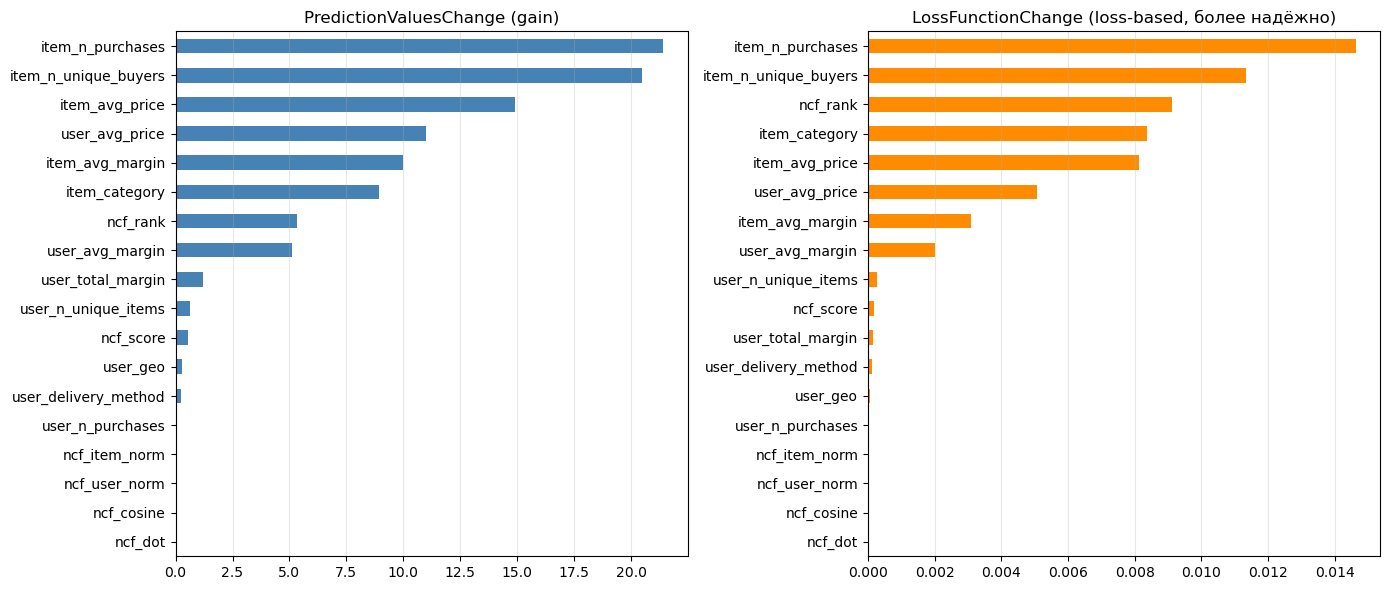

=== Топ-3 (gain) ===
item_n_purchases        21.403318
item_n_unique_buyers    20.459133
item_avg_price          14.919249

=== Топ-3 (loss-based) ===
item_n_purchases        0.014630
item_n_unique_buyers    0.011340
ncf_rank                0.009124


In [18]:
imp_gain = pd.Series(
    cb_model.get_feature_importance(type='PredictionValuesChange'),
    index=FEATURE_COLS,
).sort_values(ascending=False)

imp_loss = pd.Series(
    cb_model.get_feature_importance(type='LossFunctionChange', data=val_pool),
    index=FEATURE_COLS,
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp_gain.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('PredictionValuesChange (gain)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

imp_loss.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('LossFunctionChange (loss-based, более надёжно)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('=== Топ-3 (gain) ===')
print(imp_gain.head(3).to_string())
print('\n=== Топ-3 (loss-based) ===')
print(imp_loss.head(3).to_string())

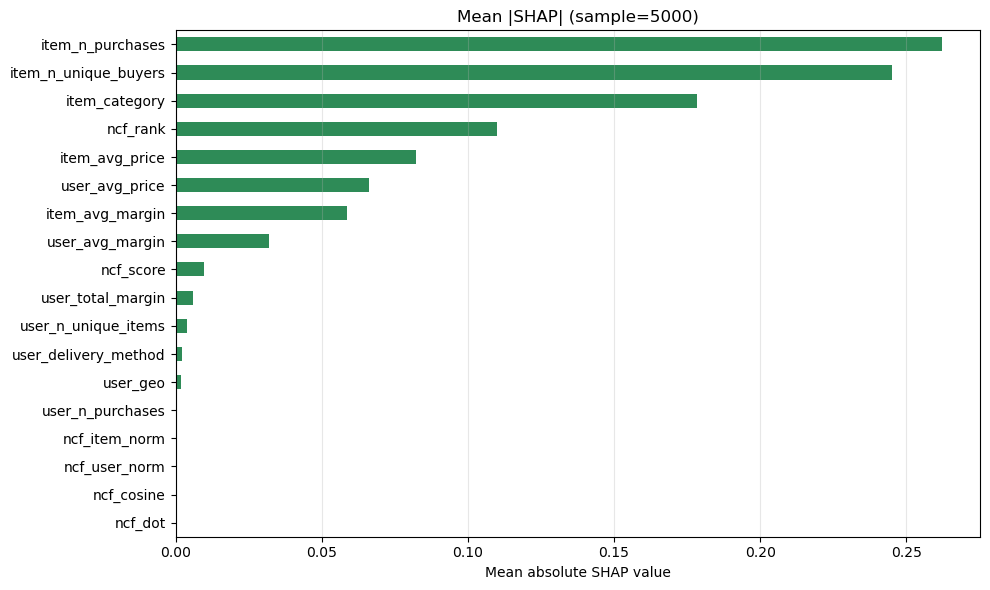

=== Топ-3 (mean |SHAP|) ===
item_n_purchases        0.262085
item_n_unique_buyers    0.245237
item_category           0.178251


In [19]:
SHAP_SAMPLE = 5000
shap_sample_df = cb_val.head(SHAP_SAMPLE).copy()
shap_pool = make_pool(shap_sample_df, FEATURE_COLS, CAT_FEATURES)
shap_values = cb_model.get_feature_importance(type='ShapValues', data=shap_pool)

shap_arr = np.asarray(shap_values)[:, :-1]
shap_df = pd.DataFrame(shap_arr, columns=FEATURE_COLS)

mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
mean_abs_shap.plot(kind='barh', ax=ax, color='seagreen')
ax.invert_yaxis()
ax.set_title(f'Mean |SHAP| (sample={SHAP_SAMPLE})')
ax.set_xlabel('Mean absolute SHAP value')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('=== Топ-3 (mean |SHAP|) ===')
print(mean_abs_shap.head(3).to_string())

if SHAP_AVAILABLE:
    num_feats = [f for f in FEATURE_COLS if f not in CAT_FEATURES]
    shap.summary_plot(
        shap_df[num_feats].values,
        shap_sample_df[num_feats].values,
        feature_names=num_feats,
        show=False,
    )
    plt.tight_layout()
    plt.show()

In [20]:
FEATURE_GROUPS = {
    'collab':           ['ncf_score', 'ncf_rank', 'ncf_dot', 'ncf_cosine', 'ncf_user_norm', 'ncf_item_norm'],
    'user_numeric':     ['user_n_purchases', 'user_n_unique_items', 'user_avg_price', 'user_total_margin', 'user_avg_margin'],
    'user_categorical': ['user_geo', 'user_delivery_method'],
    'item_numeric':     ['item_n_purchases', 'item_n_unique_buyers', 'item_avg_price', 'item_avg_margin'],
    'item_categorical': ['item_category'],
}
print({g: len(cols) for g, cols in FEATURE_GROUPS.items()})

{'collab': 6, 'user_numeric': 5, 'user_categorical': 2, 'item_numeric': 4, 'item_categorical': 1}


In [21]:
group_ablation_results = {}

for group_name, group_cols in FEATURE_GROUPS.items():
    feats = [f for f in FEATURE_COLS if f not in group_cols]
    cats  = [f for f in CAT_FEATURES if f in feats]
    print(f'-- ablate {group_name}: {len(feats)} features remain')

    tp = make_pool(cb_train, feats, cats)
    vp = make_pool(cb_val, feats, cats)
    m  = train_catboost(tp, vp, verbose=0)
    res = evaluate_hybrid(dataset, m, feats, test_user_items)
    group_ablation_results[group_name] = res
    delta = res[10]['ndcg'] - baseline_results[10]['ndcg']
    print(f'    NDCG@10 = {res[10]["ndcg"]:.4f}  (Δ vs baseline = {delta:+.4f})')

-- ablate collab: 12 features remain
    NDCG@10 = 0.0654  (Δ vs baseline = -0.0001)
-- ablate user_numeric: 13 features remain
    NDCG@10 = 0.0589  (Δ vs baseline = -0.0067)
-- ablate user_categorical: 16 features remain
    NDCG@10 = 0.0664  (Δ vs baseline = +0.0008)
-- ablate item_numeric: 14 features remain
    NDCG@10 = 0.0493  (Δ vs baseline = -0.0163)
-- ablate item_categorical: 17 features remain
    NDCG@10 = 0.0674  (Δ vs baseline = +0.0019)


                  ndcg@10  map@10  Δ_ndcg@10
item_numeric       0.0493  0.0273    -0.0163
user_numeric       0.0589  0.0337    -0.0067
collab             0.0654  0.0381    -0.0001
user_categorical   0.0664  0.0393     0.0008
item_categorical   0.0674  0.0401     0.0019


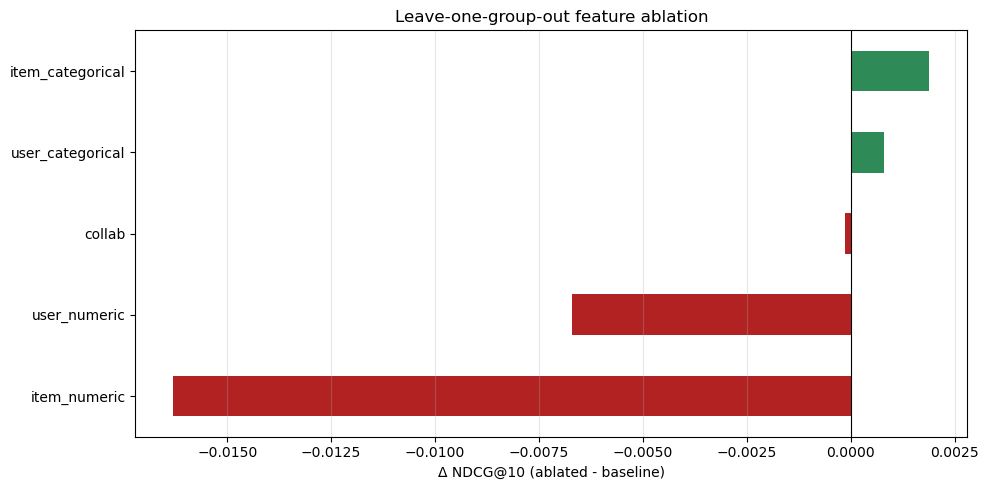

In [22]:
ablation_df = pd.DataFrame({
    g: {f'{m}@{k}': r[k][m] for k in K_VALUES for m in ['precision','recall','map','ndcg']}
    for g, r in group_ablation_results.items()
}).T
ablation_df['Δ_ndcg@10'] = ablation_df['ndcg@10'] - baseline_results[10]['ndcg']
ablation_df = ablation_df.sort_values('Δ_ndcg@10')
print(ablation_df[['ndcg@10', 'map@10', 'Δ_ndcg@10']].round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['firebrick' if d < 0 else 'seagreen' for d in ablation_df['Δ_ndcg@10']]
ablation_df['Δ_ndcg@10'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ NDCG@10 (ablated - baseline)')
ax.set_title('Leave-one-group-out feature ablation')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
TOP_N_SINGLE = 5
top_features = imp_loss.head(TOP_N_SINGLE).index.tolist()
print(f'Top-{TOP_N_SINGLE} features by LossFunctionChange: {top_features}')

single_ablation_results = {}
for feat in top_features:
    feats = [f for f in FEATURE_COLS if f != feat]
    cats  = [f for f in CAT_FEATURES if f in feats]
    print(f'-- ablate single feature: {feat}')

    tp = make_pool(cb_train, feats, cats)
    vp = make_pool(cb_val, feats, cats)
    m  = train_catboost(tp, vp, verbose=0)
    res = evaluate_hybrid(dataset, m, feats, test_user_items)
    single_ablation_results[feat] = res
    delta = res[10]['ndcg'] - baseline_results[10]['ndcg']
    print(f'    NDCG@10 = {res[10]["ndcg"]:.4f}  (Δ = {delta:+.4f})')

Top-5 features by LossFunctionChange: ['item_n_purchases', 'item_n_unique_buyers', 'ncf_rank', 'item_category', 'item_avg_price']
-- ablate single feature: item_n_purchases
    NDCG@10 = 0.0675  (Δ = +0.0019)
-- ablate single feature: item_n_unique_buyers
    NDCG@10 = 0.0686  (Δ = +0.0031)
-- ablate single feature: ncf_rank
    NDCG@10 = 0.0684  (Δ = +0.0029)
-- ablate single feature: item_category
    NDCG@10 = 0.0674  (Δ = +0.0019)
-- ablate single feature: item_avg_price
    NDCG@10 = 0.0698  (Δ = +0.0043)


In [24]:
all_variants = {'ncf_baseline': ncf_results, 'catboost_full': baseline_results}
for g, r in group_ablation_results.items():
    all_variants[f'ablate_group_{g}'] = r
for f, r in single_ablation_results.items():
    all_variants[f'ablate_feat_{f}'] = r

summary_rows = []
for name, res in all_variants.items():
    row = {'variant': name}
    for k in K_VALUES:
        for m in ['precision','recall','map','ndcg']:
            row[f'{m}@{k}'] = round(res[k][m], 4)
    row['Δ_ndcg@10'] = round(res[10]['ndcg'] - baseline_results[10]['ndcg'], 4)
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index('variant')
print(summary_df.to_string())

                                  precision@5  recall@5   map@5  ndcg@5  precision@10  recall@10  map@10  ndcg@10  precision@20  recall@20  map@20  ndcg@20  Δ_ndcg@10
variant                                                                                                                                                               
ncf_baseline                           0.0228    0.0310  0.0187  0.0310        0.0202     0.0518  0.0195   0.0374        0.0172     0.0803  0.0211   0.0463    -0.0281
catboost_full                          0.0395    0.0524  0.0392  0.0585        0.0319     0.0805  0.0387   0.0656        0.0243     0.1084  0.0397   0.0736     0.0000
ablate_group_collab                    0.0398    0.0519  0.0384  0.0577        0.0327     0.0820  0.0381   0.0654        0.0245     0.1103  0.0390   0.0733    -0.0001
ablate_group_user_numeric              0.0364    0.0462  0.0339  0.0520        0.0301     0.0727  0.0337   0.0589        0.0233     0.1030  0.0349   0.0677    -0.006

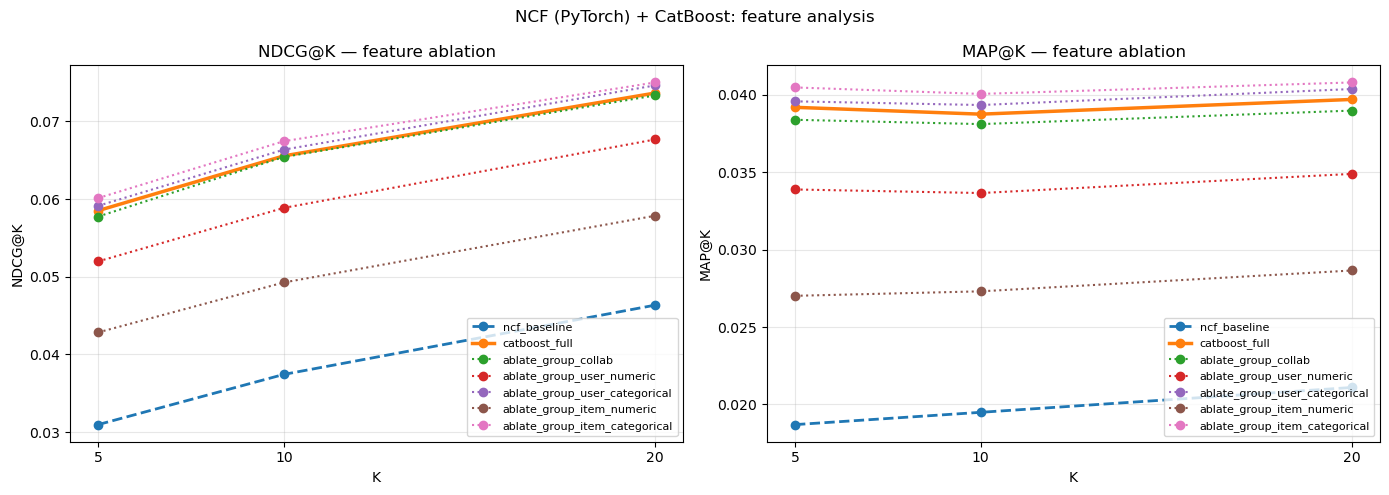

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_variants = ['ncf_baseline', 'catboost_full'] + [f'ablate_group_{g}' for g in FEATURE_GROUPS]
palette = sns.color_palette('tab10', len(plot_variants))

for ax, metric in zip(axes, ['ndcg', 'map']):
    for name, color in zip(plot_variants, palette):
        ys = [all_variants[name][k][metric] for k in K_VALUES]
        if name == 'catboost_full':
            ls, lw = '-', 2.5
        elif name == 'ncf_baseline':
            ls, lw = '--', 2.0
        else:
            ls, lw = ':', 1.5
        ax.plot(K_VALUES, ys, marker='o', label=name, color=color, linestyle=ls, linewidth=lw)
    ax.set_xlabel('K')
    ax.set_ylabel(f'{metric.upper()}@K')
    ax.set_title(f'{metric.upper()}@K — feature ablation')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(K_VALUES)

plt.suptitle('NCF (PyTorch) + CatBoost: feature analysis', fontsize=12)
plt.tight_layout()
plt.show()

## Latency benchmark: NCF + CatBoost (two-stage)

Замеры per-user latency:
- **stage1**: NCF top-100 кандидатов на GPU (single + batch_amortized режимы)
- **stage2**: CatBoost rerank на заготовленных 100 кандидатах (CPU only — модель содержит категориальные фичи)
- **e2e**: NCF → построение фичей → CatBoost predict → top-K

In [ ]:
import sys
from pathlib import Path
_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    _utils = _cand / 'source' / 'utils'
    if _utils.exists():
        sys.path.insert(0, str(_utils))
        break
import importlib, timing as _t
importlib.reload(_t)
from timing import benchmark_user_latency, benchmark_batch_latency, save_benchmark, detect_hardware

rng = np.random.RandomState(SEED)
sample_size = min(2000, len(eval_users))
bench_users = rng.choice(eval_users, size=sample_size, replace=False).tolist()

ncf_model.eval()
ncf_model.to(device)
_use_cuda = (device.type == 'cuda')
hw = detect_hardware(prefer='gpu') if _use_cuda else detect_hardware(prefer='cpu')
print(f'Benchmarking on {len(bench_users)} users (device={device}, sync_cuda={_use_cuda}, N_CANDIDATES={N_CANDIDATES})')

DATASET_META = {
    'n_users': int(N_USERS), 'n_items': int(N_ITEMS),
    'n_candidates': int(N_CANDIDATES),
    'n_train_pairs': int(len(train_df)),
    'min_interactions': MIN_INTERACTIONS,
    'split_quantile': SPLIT_QUANTILE,
}
NCF_EXTRA_BASE = {
    'library': 'torch_custom_neumf',
    'n_factors': NCF_BEST_N_FACTORS, 'layers': NCF_BEST_LAYERS,
    'n_neg': NCF_BEST_N_NEG, 'dropout': NCF_BEST_DROPOUT,
    'final_epochs': NCF_FINAL_EPOCHS, 'sync_cuda': _use_cuda,
}

In [ ]:
import torch
_item_t_full = torch.arange(N_ITEMS, device=device)

@torch.no_grad()
def ncf_stage1_single(uid):
    u = torch.full((N_ITEMS,), int(uid), device=device, dtype=torch.long)
    scores = ncf_model(u, _item_t_full)
    bought = train_user_bought.get(uid, set())
    if bought:
        idx = [it for it in bought if it < N_ITEMS]
        if idx:
            scores[torch.tensor(idx, device=device, dtype=torch.long)] = float('-inf')
    top_scores, top_idx = torch.topk(scores, N_CANDIDATES)
    return top_idx.cpu().numpy(), top_scores.cpu().numpy()

stats_s1_single = benchmark_user_latency(
    ncf_stage1_single, bench_users, warmup=100, k=10, sync_cuda=_use_cuda,
    label='NCF+CB stage1 single'
)
print(f"NCF stage1 single ({device}): mean={stats_s1_single['mean_ms']:.3f}ms  p50={stats_s1_single['p50_ms']:.3f}  p95={stats_s1_single['p95_ms']:.3f}")
save_benchmark(
    stats_s1_single, model_name='NCF-PyTorch+CatBoost', stage='stage1',
    hardware=hw, dataset_meta=DATASET_META,
    extra={**NCF_EXTRA_BASE, 'mode_desc': 'NCF top-N=100 candidates, single user'},
    notebook='experiments/ncf_pytorch_catboost_experiments.ipynb', n_items=N_ITEMS,
)

# --- stage1 NCF batch_amortized ---
USER_BATCH = 32
@torch.no_grad()
def ncf_stage1_batch(user_ids_chunk):
    b = len(user_ids_chunk)
    u = torch.tensor(user_ids_chunk, device=device, dtype=torch.long).unsqueeze(1).expand(b, N_ITEMS).reshape(-1)
    v = _item_t_full.unsqueeze(0).expand(b, -1).reshape(-1)
    scores = ncf_model(u, v).reshape(b, N_ITEMS)
    return torch.topk(scores, N_CANDIDATES, dim=1).indices.cpu()

stats_s1_batch = benchmark_batch_latency(
    ncf_stage1_batch, bench_users, batch_size=USER_BATCH, warmup_batches=2,
    k=10, sync_cuda=_use_cuda, label='NCF+CB stage1 batch32'
)
print(f"NCF stage1 batch{USER_BATCH} amortized: mean={stats_s1_batch['mean_ms']:.3f}ms  p50={stats_s1_batch['p50_ms']:.3f}  p95={stats_s1_batch['p95_ms']:.3f}")
save_benchmark(
    stats_s1_batch, model_name='NCF-PyTorch+CatBoost', stage='stage1',
    hardware=hw, dataset_meta=DATASET_META,
    extra={**NCF_EXTRA_BASE, 'user_batch': USER_BATCH,
           'mode_desc': 'NCF top-N=100, batched amortized'},
    notebook='experiments/ncf_pytorch_catboost_experiments.ipynb', n_items=N_ITEMS,
)

In [ ]:
# --- stage2 CatBoost rerank only (на заготовленных 100 кандидатах; CPU only из-за categorical) ---
feat_by_user = {
    int(u): grp[FEATURE_COLS].copy()
    for u, grp in dataset.groupby('user_id')
}
bench_users_present = [u for u in bench_users if u in feat_by_user]
print(f'feat_by_user: {len(feat_by_user)} users; bench пересечение: {len(bench_users_present)}')

def cb_stage2(uid):
    feats = feat_by_user[uid]
    scores = cb_model.predict(feats)
    order = np.argsort(-scores)
    return order[:10]

stats_s2 = benchmark_user_latency(
    cb_stage2, bench_users_present, warmup=50, k=10, sync_cuda=False, label='NCF+CB stage2 CPU'
)
print(f"CatBoost stage2: mean={stats_s2['mean_ms']:.3f}ms  p50={stats_s2['p50_ms']:.3f}  p95={stats_s2['p95_ms']:.3f}")
save_benchmark(
    stats_s2, model_name='NCF-PyTorch+CatBoost', stage='stage2',
    hardware=detect_hardware(prefer='cpu'),
    dataset_meta=DATASET_META,
    extra={'library': 'catboost', 'cat_features': CAT_FEATURES,
           'n_features': len(FEATURE_COLS),
           'best_iteration': int(cb_model.get_best_iteration()),
           'task_type': 'CPU',
           'stage_desc': 'CatBoost rerank on prebuilt 100-cand DataFrame'},
    notebook='experiments/ncf_pytorch_catboost_experiments.ipynb', n_items=N_ITEMS,
)

In [ ]:
# --- e2e: NCF stage1 single + on-the-fly features + CatBoost predict ---
_uf_by_user = user_features.set_index('user_id').to_dict('index')
_if_by_item = item_features.set_index('item_id').to_dict('index')
user_emb_arr = ncf_model.user_emb_gmf.weight.detach().cpu().numpy()
item_emb_arr = ncf_model.item_emb_gmf.weight.detach().cpu().numpy()

def _build_feats(uid, item_ids, scores):
    n = len(item_ids)
    item_ids_arr = np.asarray(item_ids, dtype=np.int64)
    scores_arr = np.asarray(scores, dtype=np.float64)
    u_vec = user_emb_arr[uid]
    i_vecs = item_emb_arr[item_ids_arr]
    ncf_dot = (i_vecs * u_vec).sum(axis=1)
    u_norm = float(np.linalg.norm(u_vec))
    i_norms = np.linalg.norm(i_vecs, axis=1)
    ncf_cos = ncf_dot / (u_norm * i_norms + 1e-10)
    ranks = np.arange(1, n + 1)

    uf = _uf_by_user.get(uid, {})
    item_n_purchases = np.empty(n)
    item_n_unique_buyers = np.empty(n)
    item_avg_price = np.empty(n)
    item_avg_margin = np.empty(n)
    item_category = []
    for j, it in enumerate(item_ids_arr):
        ifr = _if_by_item.get(int(it), {})
        item_n_purchases[j] = ifr.get('item_n_purchases', 0)
        item_n_unique_buyers[j] = ifr.get('item_n_unique_buyers', 0)
        item_avg_price[j] = ifr.get('item_avg_price', 0.0)
        item_avg_margin[j] = ifr.get('item_avg_margin', 0.0)
        item_category.append(ifr.get('item_category', 'Неизвестно'))
    return pd.DataFrame({
        'ncf_score': scores_arr, 'ncf_rank': ranks,
        'ncf_dot': ncf_dot, 'ncf_cosine': ncf_cos,
        'ncf_user_norm': np.full(n, u_norm), 'ncf_item_norm': i_norms,
        'user_n_purchases': uf.get('user_n_purchases', 0),
        'user_n_unique_items': uf.get('user_n_unique_items', 0),
        'user_avg_price': uf.get('user_avg_price', 0.0),
        'user_total_margin': uf.get('user_total_margin', 0.0),
        'user_avg_margin': uf.get('user_avg_margin', 0.0),
        'user_geo': uf.get('user_geo', 'Неизвестно'),
        'user_delivery_method': uf.get('user_delivery_method', 'Неизвестно'),
        'item_n_purchases': item_n_purchases,
        'item_n_unique_buyers': item_n_unique_buyers,
        'item_avg_price': item_avg_price,
        'item_avg_margin': item_avg_margin,
        'item_category': item_category,
    })


def e2e_ncf_cb(uid):
    item_ids, scores = ncf_stage1_single(uid)
    feats = _build_feats(uid, item_ids, scores)
    cb_scores = cb_model.predict(feats[FEATURE_COLS])
    order = np.argsort(-cb_scores)
    return [int(item_ids[i]) for i in order[:10]]

stats_e2e = benchmark_user_latency(
    e2e_ncf_cb, bench_users, warmup=100, k=10, sync_cuda=_use_cuda, label='NCF+CB e2e'
)
print(f"NCF+CB e2e: mean={stats_e2e['mean_ms']:.3f}ms  p50={stats_e2e['p50_ms']:.3f}  p95={stats_e2e['p95_ms']:.3f}")
save_benchmark(
    stats_e2e, model_name='NCF-PyTorch+CatBoost', stage='e2e',
    hardware=hw, dataset_meta=DATASET_META,
    extra={**NCF_EXTRA_BASE, 'cb_task_type': 'CPU',
           'stage_desc': 'NCF single user top-100 + on-the-fly features + CatBoost predict + top-10'},
    notebook='experiments/ncf_pytorch_catboost_experiments.ipynb', n_items=N_ITEMS,
)